# MAI511-2 – Advanced Machine Learning

## Regularized Regression using Lasso and Ridge with Cross-Validation and Grid Search

### Lab Exercise 2

**Dataset:** Appliances Energy Prediction  
**Domain:** Smart Home / IoT  
**Problem Type:** Regression

### Objective
To implement and compare Lasso Regression and Ridge Regression using Cross-Validation and Grid Search to identify the optimal value of alpha.

## 1. Dataset Selection and Loading

### Dataset: Appliances Energy Prediction

The Appliances Energy Prediction dataset is a Smart Home / IoT dataset used to predict appliance energy consumption.

The dataset contains:
- 19,735 instances
- 28 input features
- 1 continuous target variable
- Target variable: `Appliances`

The problem is treated as a regression problem because the target represents energy consumption.

### Source
UCI Machine Learning Repository:
https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Loading the Dataset

The dataset is loaded using Pandas. After loading, the first few records are displayed to understand the structure of the data.

In [51]:
# Load the dataset
df = pd.read_csv("energydata_complete.csv")

# Display first 5 rows
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


### Dataset Dimensions

The shape of the dataset is checked to determine the number of rows and columns.

In [52]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (19735, 29)


### Column Names

The column names are displayed to identify the available features and the target variable.

In [53]:
print("Column names:")
print(df.columns.tolist())

Column names:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


### Dataset Information

The `info()` function is used to examine:
- Number of entries
- Column names
- Data types
- Non-null values

This helps identify numerical and categorical variables and possible missing values.

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

### Checking Missing Values

Missing values are checked in each column. Identifying missing values is an important preprocessing step before building the regression models.

In [55]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


### Checking Duplicate Records

Duplicate rows are checked because repeated observations may affect the training of the regression models.

In [56]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### Descriptive Statistics

Descriptive statistics are calculated to understand the distribution and range of the numerical variables.

The statistics include:
- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

In [57]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


## 2. Data Exploration

Data exploration is performed to understand the structure, distribution, and relationships within the dataset.

The following steps are performed:
- Identify numerical and categorical features
- Check missing values
- Check duplicate records
- Calculate descriptive statistics
- Visualize selected features against appliance energy consumption

### Identifying the Target Variable

The target variable for this regression problem is `Appliances`.

It represents the energy consumption of appliances. The remaining variables are considered input features for predicting appliance energy consumption.

In [58]:
# Separate features and target

X = df.drop("Appliances", axis=1)
y = df["Appliances"]

print("Number of features:", X.shape[1])
print("Target variable:", y.name)

Number of features: 28
Target variable: Appliances


### Identifying Numerical and Categorical Features

The data types of the columns are examined to identify numerical and categorical variables.

Numerical variables can be directly used after appropriate preprocessing, while categorical variables, if present, need to be encoded before model training.

In [59]:
# Identify numerical and categorical columns

numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(exclude=np.number).columns

print("Number of numerical features:", len(numerical_features))
print("Numerical features:")
print(list(numerical_features))

print("\nNumber of categorical features:", len(categorical_features))
print("Categorical features:")
print(list(categorical_features))

Number of numerical features: 27
Numerical features:
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']

Number of categorical features: 1
Categorical features:
['date']


### Distribution of Appliance Energy Consumption

The distribution of the target variable `Appliances` is visualized using a histogram.

This helps understand how appliance energy consumption is distributed across the observations.

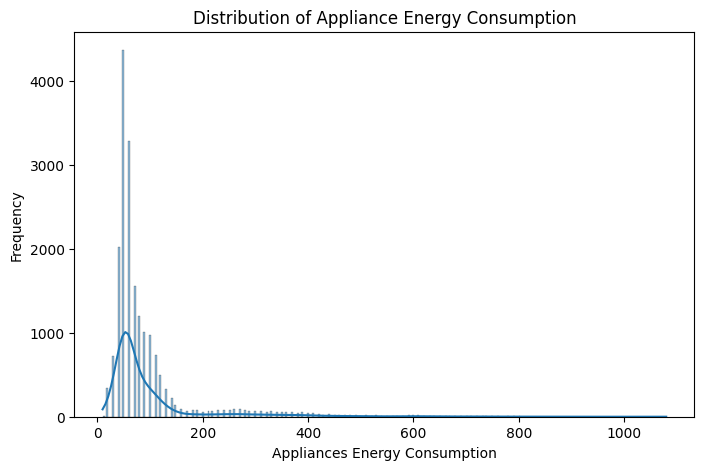

In [60]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Appliances"], kde=True)

plt.title("Distribution of Appliance Energy Consumption")
plt.xlabel("Appliances Energy Consumption")
plt.ylabel("Frequency")

plt.show()

### Relationship Between Selected Features and Target

Scatter plots are used to visualize the relationship between selected input features and appliance energy consumption.

The following features are selected:
- Temperature in the living room
- Humidity in the living room
- Temperature outside
- Humidity outside

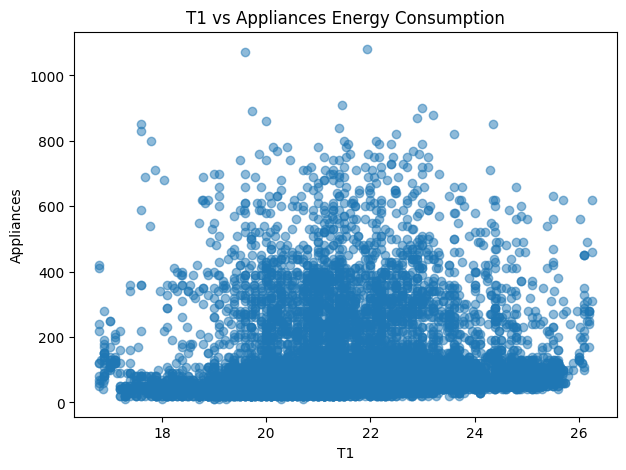

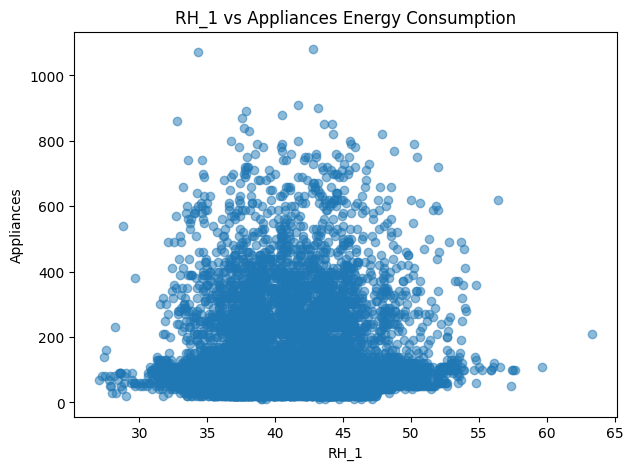

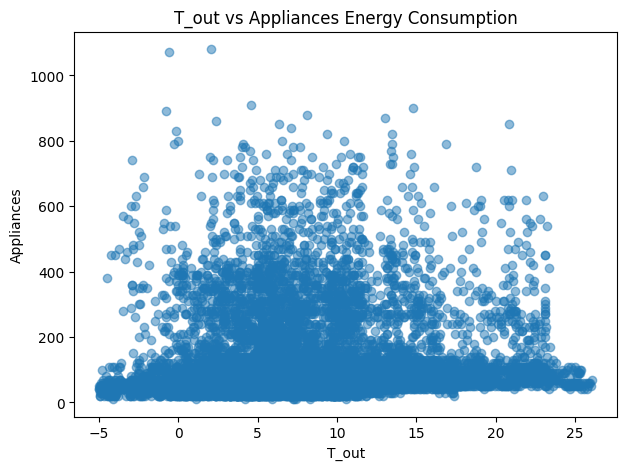

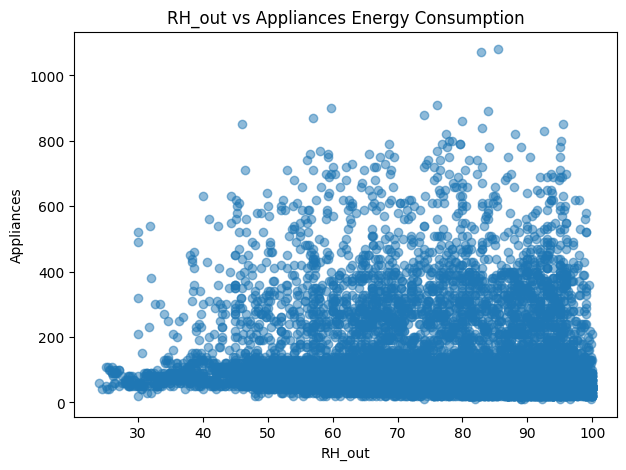

In [61]:
selected_features = [
    "T1",
    "RH_1",
    "T_out",
    "RH_out"
]

for feature in selected_features:
    plt.figure(figsize=(7, 5))

    plt.scatter(df[feature], df["Appliances"], alpha=0.5)

    plt.title(f"{feature} vs Appliances Energy Consumption")
    plt.xlabel(feature)
    plt.ylabel("Appliances")

    plt.show()

### Correlation Analysis

Correlation is used to examine the linear relationship between numerical variables and appliance energy consumption.

A correlation value close to:
- +1 indicates a strong positive relationship.
- -1 indicates a strong negative relationship.
- 0 indicates a weak or no linear relationship.

In [62]:
# Correlation with target variable

correlation = df[numerical_features.tolist() + ["Appliances"]].corr()

print("Correlation with Appliances:")
print(correlation["Appliances"].sort_values(ascending=False))

Correlation with Appliances:
Appliances     1.000000
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


### Correlation Heatmap

A heatmap is used to visualize the correlations between the numerical variables.

This helps identify features that may have stronger relationships with appliance energy consumption and also helps identify relationships among input features.

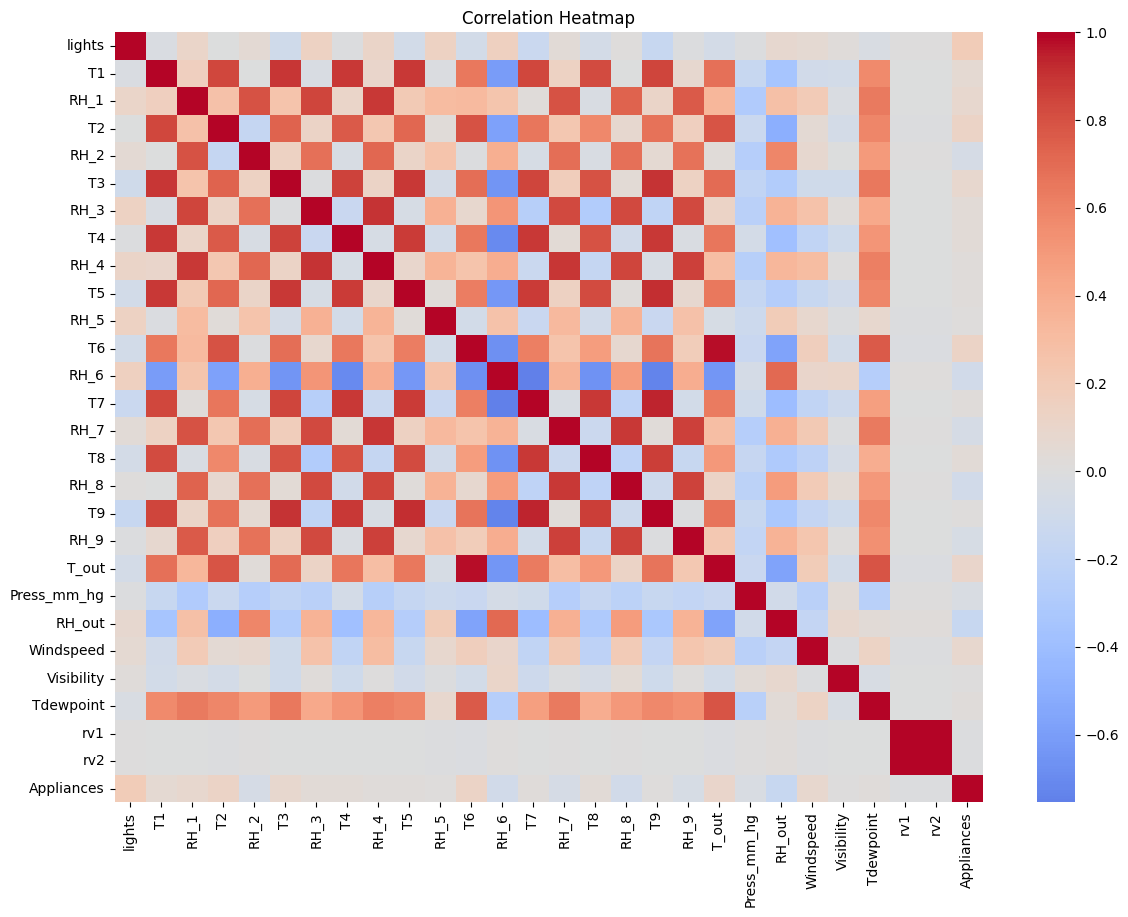

In [63]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation

The exploratory analysis helps identify relationships between the input variables and appliance energy consumption.

Features showing stronger correlations with `Appliances` may provide more useful information for prediction. The correlation analysis also helps identify relationships between input features, which is important when applying regularization techniques such as Lasso and Ridge.

The analysis will be used to guide the preprocessing and regression modelling stages.

## 3. Data Preprocessing

Data preprocessing is performed before building the regression models.

The following steps are carried out:
- Convert the date column into useful numerical features
- Remove the original date column
- Separate input features and target variable
- Split the dataset into training and testing sets
- Scale the features using StandardScaler

Feature scaling is particularly important for Lasso and Ridge Regression because regularization depends on the magnitude of the coefficients.

### Processing the Date Feature

The dataset contains a `date` column that represents the date and time of each observation.

Machine learning models cannot directly use the date string. Therefore, useful information such as hour, day, month, and day of the week is extracted from the date column.

In [64]:
# Convert date column to datetime

df["date"] = pd.to_datetime(df["date"])

# Extract useful time-based features

df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

# Remove original date column

df = df.drop("date", axis=1)

print(df.head())

   Appliances  lights     T1       RH_1    T2       RH_2     T3       RH_3  \
0          60      30  19.89  47.596667  19.2  44.790000  19.79  44.730000   
1          60      30  19.89  46.693333  19.2  44.722500  19.79  44.790000   
2          50      30  19.89  46.300000  19.2  44.626667  19.79  44.933333   
3          50      40  19.89  46.066667  19.2  44.590000  19.79  45.000000   
4          60      40  19.89  46.333333  19.2  44.530000  19.79  45.000000   

          T4       RH_4  ...  RH_out  Windspeed  Visibility  Tdewpoint  \
0  19.000000  45.566667  ...    92.0   7.000000   63.000000        5.3   
1  19.000000  45.992500  ...    92.0   6.666667   59.166667        5.2   
2  18.926667  45.890000  ...    92.0   6.333333   55.333333        5.1   
3  18.890000  45.723333  ...    92.0   6.000000   51.500000        5.0   
4  18.890000  45.530000  ...    92.0   5.666667   47.666667        4.9   

         rv1        rv2  hour  day  month  day_of_week  
0  13.275433  13.275433    17

### Separating Features and Target

The dataset is divided into:

- `X` – input features
- `y` – target variable (`Appliances`)

The target variable is removed from `X` because it is the value that the model needs to predict.

In [65]:
# Separate input features and target

X = df.drop("Appliances", axis=1)
y = df["Appliances"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19735, 31)
y shape: (19735,)


### Train-Test Split

The dataset is divided into training and testing data.

- 80% of the data is used for training.
- 20% of the data is used for testing.

The training data is used to learn the regression models, while the testing data is used to evaluate how well the models generalize to unseen data.

`random_state=42` is used to obtain the same split each time the code is executed.

In [66]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (15788, 31)
Testing data: (3947, 31)


### Feature Scaling

StandardScaler is used to standardize the input features.

The training data is used to calculate the mean and standard deviation.

The same transformation is then applied to the test data.

This prevents information from the test dataset from being used during training and helps Lasso and Ridge treat features on comparable scales.

In [67]:
# Create scaler

scaler = StandardScaler()

# Fit scaler only on training data

X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler

X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (15788, 31)
Scaled testing data shape: (3947, 31)


### Preprocessing Summary

The following preprocessing steps have been completed:

1. Converted the date column into numerical time-based features.
2. Removed the original date column.
3. Separated the input features and target variable.
4. Split the dataset into training and testing sets.
5. Standardized the features using StandardScaler.

The processed data is now ready for regression modelling.

## 4. Baseline Model – Linear Regression

Linear Regression is used as the baseline model for predicting appliance energy consumption.

The model learns the relationship between the input features and the continuous target variable `Appliances`.

The performance of the model is evaluated using:
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

These results will be used as the baseline for comparison with Lasso and Ridge Regression.

### Building the Linear Regression Model

A Linear Regression model is trained using the scaled training data.

The trained model is then used to predict appliance energy consumption for the unseen test data.

In [68]:
# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


### Model Evaluation

The Linear Regression model is evaluated using four regression metrics.

**MAE:** Measures the average absolute difference between actual and predicted values.

**MSE:** Measures the average squared difference between actual and predicted values.

**RMSE:** Represents the square root of MSE and is expressed in the same unit as the target.

**R² Score:** Measures how much of the variation in the target variable is explained by the model.

In [69]:
# Calculate evaluation metrics

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE  :", mae_linear)
print("MSE  :", mse_linear)
print("RMSE :", rmse_linear)
print("R²   :", r2_linear)

Linear Regression Performance
--------------------------------
MAE  : 52.56973424453629
MSE  : 8303.5409291266
RMSE : 91.1237670924913
R²   : 0.1702343017489495


### Storing Baseline Results

The evaluation results are stored in a DataFrame so that they can later be compared with the Lasso and Ridge Regression models.

In [70]:
# Store Linear Regression results

results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae_linear],
    "MSE": [mse_linear],
    "RMSE": [rmse_linear],
    "R2": [r2_linear]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,52.569734,8303.540929,91.123767,0.170234


### Interpretation

The Linear Regression model provides the baseline performance for the regression problem.

Lower values of MAE, MSE, and RMSE indicate lower prediction error, while a higher R² score indicates that the model explains more variation in appliance energy consumption.

The baseline results will be compared with Lasso and Ridge Regression after hyperparameter tuning using GridSearchCV.

### Actual vs Predicted Values

The following plot compares the actual appliance energy consumption with the values predicted by the Linear Regression model.

A prediction closer to the diagonal relationship indicates better agreement between actual and predicted values.

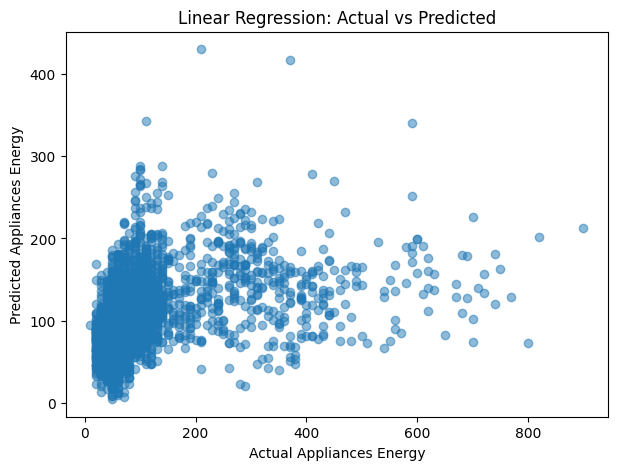

In [71]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

plt.xlabel("Actual Appliances Energy")
plt.ylabel("Predicted Appliances Energy")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

## 5. Lasso Regression with Grid Search

Lasso Regression uses L1 regularization to reduce the magnitude of model coefficients.

One important property of Lasso Regression is that it can reduce some coefficients exactly to zero. Therefore, it can also perform feature selection.

The regularization strength is controlled by the `alpha` hyperparameter.

GridSearchCV with 5-fold cross-validation is used to identify the value of `alpha` that provides the best cross-validation performance.

### Defining Alpha Values

Different values of `alpha` are tested using GridSearchCV.

A smaller alpha applies weaker regularization, while a larger alpha applies stronger regularization.

In [72]:
# Define Lasso model
lasso = Lasso(max_iter=10000)

# Define alpha values
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

# Define parameter grid
lasso_param_grid = {
    "alpha": alpha_values
}

### Lasso Grid Search with 5-Fold Cross-Validation

GridSearchCV evaluates each alpha value using 5-fold cross-validation.

The dataset is divided into five parts. In each iteration, four parts are used for training and one part is used for validation.

This process is repeated until every part has been used as the validation set.

In [73]:
# Create GridSearchCV

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=lasso_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Perform grid search
lasso_grid.fit(X_train_scaled, y_train)

print("Best Alpha:", lasso_grid.best_params_["alpha"])
print("Best CV MSE:", -lasso_grid.best_score_)

Best Alpha: 0.01
Best CV MSE: 8879.901851377677


### Selecting the Best Lasso Model

The best alpha identified by GridSearchCV is used to create the final Lasso model.

The final model is evaluated using the unseen test dataset.

In [74]:
# Get the best Lasso model
best_lasso = lasso_grid.best_estimator_

# Predict on test data
y_pred_lasso = best_lasso.predict(X_test_scaled)

print("Best Lasso model selected successfully.")

Best Lasso model selected successfully.


### Evaluating Lasso Regression

The Lasso model is evaluated using MAE, MSE, RMSE, and R².

These metrics are compared with the baseline Linear Regression model.

In [75]:
# Calculate Lasso metrics

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Performance")
print("--------------------------------")
print("MAE  :", mae_lasso)
print("MSE  :", mse_lasso)
print("RMSE :", rmse_lasso)
print("R²   :", r2_lasso)

Lasso Regression Performance
--------------------------------
MAE  : 52.5499760679578
MSE  : 8302.659885687803
RMSE : 91.11893264128922
R²   : 0.17032234366148102


### Comparing Linear Regression and Lasso

The Linear Regression and Lasso Regression results are compared using the four evaluation metrics.

This comparison helps determine whether regularization improves the baseline model's performance.

In [76]:
# Add Lasso results

results.loc[len(results)] = [
    "Lasso Regression",
    mae_lasso,
    mse_lasso,
    rmse_lasso,
    r2_lasso
]

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,52.569734,8303.540929,91.123767,0.170234
1,Lasso Regression,52.549976,8302.659886,91.118933,0.170322


### Lasso Coefficient Analysis

Lasso can shrink some coefficients to exactly zero.

Features with zero coefficients are effectively excluded from the model.

The number of zero coefficients is calculated to demonstrate the feature-selection property of Lasso.

In [77]:
# Get Lasso coefficients

lasso_coefficients = pd.Series(
    best_lasso.coef_,
    index=X.columns
)

# Count zero coefficients
zero_coefficients = (lasso_coefficients == 0).sum()

print("Number of zero coefficients:", zero_coefficients)
print("\nLasso coefficients:")
print(lasso_coefficients.sort_values())

Number of zero coefficients: 0

Lasso coefficients:
RH_2          -5.369551e+01
T_out         -3.972058e+01
T2            -3.969219e+01
RH_8          -1.885289e+01
month         -1.808548e+01
T9            -1.733945e+01
RH_7          -8.419950e+00
T1            -5.740600e+00
RH_4          -5.115981e+00
T4            -4.889647e+00
RH_9          -3.471156e+00
RH_out        -2.953028e+00
day           -1.824466e+00
T5            -1.210451e+00
rv2            1.512176e-16
rv1            8.512467e-02
RH_5           9.221628e-01
Press_mm_hg    1.316689e+00
Visibility     2.028776e+00
RH_6           2.405414e+00
T7             2.809527e+00
Windspeed      3.844009e+00
day_of_week    3.984992e+00
hour           6.719399e+00
Tdewpoint      9.416818e+00
RH_3           1.185519e+01
T8             1.242928e+01
lights         1.476248e+01
T6             4.365313e+01
T3             5.609855e+01
RH_1           6.033466e+01
dtype: float64


### Interpretation

The optimal `alpha` is selected using 5-fold cross-validation.

Lasso regularization reduces the magnitude of the regression coefficients. Some coefficients may become exactly zero, which indicates that the corresponding features were not required by the regularized model.

The Lasso test-set metrics will later be compared with Linear Regression and Ridge Regression.

### Cross-Validation Performance for Different Alpha Values

The mean cross-validation performance for each tested alpha value can be visualized to understand how the regularization strength affects the Lasso model.

In [78]:
# Extract GridSearchCV results

lasso_cv_results = pd.DataFrame(lasso_grid.cv_results_)

# Convert negative MSE to positive MSE
lasso_cv_results["Mean_MSE"] = -lasso_cv_results["mean_test_score"]

# Display alpha and CV MSE
print(lasso_cv_results[["param_alpha", "Mean_MSE"]])

   param_alpha      Mean_MSE
0        0.001   8880.136359
1        0.010   8879.901851
2        0.100   8883.129634
3        1.000   9049.976018
4       10.000  10055.497344
5      100.000  10638.684044


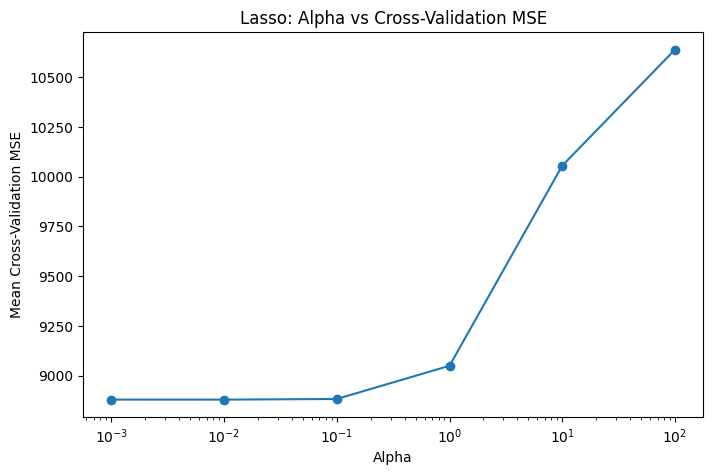

In [79]:
plt.figure(figsize=(8, 5))

plt.plot(
    lasso_cv_results["param_alpha"].astype(float),
    lasso_cv_results["Mean_MSE"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("Lasso: Alpha vs Cross-Validation MSE")

plt.show()

## 6. Ridge Regression with Grid Search

Ridge Regression uses L2 regularization to reduce the magnitude of regression coefficients.

Unlike Lasso, Ridge generally does not reduce coefficients exactly to zero. Instead, it shrinks the coefficients toward zero.

The regularization strength is controlled by the `alpha` hyperparameter.

GridSearchCV with 5-fold cross-validation is used to identify the optimal value of `alpha`.

### Defining Alpha Values

The same range of alpha values used for Lasso is tested for Ridge Regression.

This allows the two regularization techniques to be compared under similar conditions.

In [80]:
# Define Ridge model
ridge = Ridge()

# Define alpha values
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

# Define parameter grid
ridge_param_grid = {
    "alpha": alpha_values
}

### Ridge Grid Search with 5-Fold Cross-Validation

GridSearchCV evaluates different alpha values using 5-fold cross-validation.

The alpha that produces the best cross-validation performance is selected for the final Ridge model.

In [81]:
# Create GridSearchCV for Ridge

ridge_grid = GridSearchCV(
    estimator=ridge,
    param_grid=ridge_param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Perform grid search
ridge_grid.fit(X_train_scaled, y_train)

print("Best Alpha:", ridge_grid.best_params_["alpha"])
print("Best CV MSE:", -ridge_grid.best_score_)

Best Alpha: 10
Best CV MSE: 8879.974298372497


### Selecting the Best Ridge Model

The Ridge model with the best alpha selected by GridSearchCV is used to make predictions on the test dataset.

In [82]:
# Get the best Ridge model
best_ridge = ridge_grid.best_estimator_

# Make predictions
y_pred_ridge = best_ridge.predict(X_test_scaled)

print("Best Ridge model selected successfully.")

Best Ridge model selected successfully.


### Evaluating Ridge Regression

The Ridge Regression model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The results will be compared with Linear Regression and Lasso Regression.

In [83]:
# Calculate Ridge metrics

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Performance")
print("--------------------------------")
print("MAE  :", mae_ridge)
print("MSE  :", mse_ridge)
print("RMSE :", rmse_ridge)
print("R²   :", r2_ridge)

Ridge Regression Performance
--------------------------------
MAE  : 52.53727937919085
MSE  : 8301.771993684817
RMSE : 91.11406035121482
R²   : 0.17041106994513722


### Adding Ridge Results to the Model Comparison

The Ridge Regression results are added to the existing results table so that all three models can be compared.

In [84]:
# Add Ridge results

results.loc[len(results)] = [
    "Ridge Regression",
    mae_ridge,
    mse_ridge,
    rmse_ridge,
    r2_ridge
]

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,52.569734,8303.540929,91.123767,0.170234
1,Lasso Regression,52.549976,8302.659886,91.118933,0.170322
2,Ridge Regression,52.537279,8301.771994,91.114060,0.170411


### Ridge Coefficient Analysis

The coefficients learned by Ridge Regression are examined to understand the effect of L2 regularization.

Ridge generally keeps all features in the model but reduces the magnitude of their coefficients.

In [85]:
# Get Ridge coefficients

ridge_coefficients = pd.Series(
    best_ridge.coef_,
    index=X.columns
)

print("Ridge coefficients:")
print(ridge_coefficients.sort_values())

Ridge coefficients:
RH_2          -52.307417
T2            -38.042712
T_out         -38.019550
RH_8          -18.738986
month         -18.078094
T9            -17.342332
RH_7           -8.563066
T1             -6.544712
RH_4           -5.381429
T4             -5.079416
RH_9           -3.565933
RH_out         -2.519510
day            -1.805490
T5             -1.392027
rv2             0.046010
rv1             0.046010
RH_5            0.928258
Press_mm_hg     1.312297
Visibility      2.028515
RH_6            2.331603
T7              2.990692
Windspeed       3.876575
day_of_week     3.981443
hour            6.723515
Tdewpoint       8.794912
RH_3           11.877023
T8             12.384153
lights         14.804751
T6             42.527717
T3             55.971928
RH_1           59.350943
dtype: float64


### Cross-Validation Performance for Different Alpha Values

The cross-validation performance obtained for each alpha value is examined to understand how the regularization strength affects Ridge Regression.

In [86]:
# Extract Ridge GridSearchCV results

ridge_cv_results = pd.DataFrame(ridge_grid.cv_results_)

# Convert negative MSE to positive MSE
ridge_cv_results["Mean_MSE"] = -ridge_cv_results["mean_test_score"]

print(ridge_cv_results[["param_alpha", "Mean_MSE"]])

   param_alpha     Mean_MSE
0        0.001  8880.161597
1        0.010  8880.160826
2        0.100  8880.153192
3        1.000  8880.084260
4       10.000  8879.974298
5      100.000  8896.245676


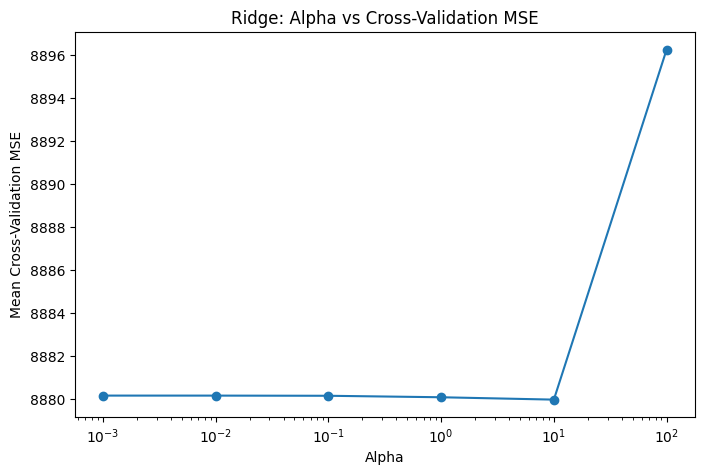

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(
    ridge_cv_results["param_alpha"].astype(float),
    ridge_cv_results["Mean_MSE"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Mean Cross-Validation MSE")
plt.title("Ridge: Alpha vs Cross-Validation MSE")

plt.show()

### Interpretation

The optimal alpha for Ridge Regression is selected using 5-fold cross-validation.

Ridge regularization reduces the magnitude of the regression coefficients. Unlike Lasso, Ridge generally retains all features instead of setting coefficients exactly to zero.

The Ridge results will now be compared with the Linear Regression and Lasso Regression models.

## 7. Model Comparison

The performance of Linear Regression, Lasso Regression, and Ridge Regression is compared using the test dataset.

The following metrics are considered:

- MAE
- MSE
- RMSE
- R² Score

For MAE, MSE, and RMSE, lower values indicate lower prediction error.

For R², a higher value indicates that the model explains more variation in the target variable.

The optimal alpha values obtained through GridSearchCV are also reported for Lasso and Ridge.

In [88]:
# Display model comparison

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,52.569734,8303.540929,91.123767,0.170234
1,Lasso Regression,52.549976,8302.659886,91.118933,0.170322
2,Ridge Regression,52.537279,8301.771994,91.114060,0.170411


### Optimal Alpha Values

GridSearchCV was used to identify the optimal regularization strength for Lasso and Ridge Regression.

The selected alpha values are displayed below.

In [89]:
print("Optimal Alpha Values")
print("--------------------")
print("Lasso Alpha:", lasso_grid.best_params_["alpha"])
print("Ridge Alpha:", ridge_grid.best_params_["alpha"])

Optimal Alpha Values
--------------------
Lasso Alpha: 0.01
Ridge Alpha: 10


### Comparing Model Coefficients

The coefficients of Lasso and Ridge are compared to understand the effect of regularization.

Lasso can set some coefficients exactly to zero, which performs feature selection.

Ridge generally retains all features but reduces the magnitude of their coefficients.

In [90]:
# Create coefficient comparison table

coefficient_comparison = pd.DataFrame({
    "Feature": X.columns,
    "Lasso": best_lasso.coef_,
    "Ridge": best_ridge.coef_
})

coefficient_comparison

,Feature,Lasso,Ridge
0,lights,1.476248e+01,14.804751
1,T1,-5.740600e+00,-6.544712
2,RH_1,6.033466e+01,59.350943
3,T2,-3.969219e+01,-38.042712
4,RH_2,-5.369551e+01,-52.307417
5,T3,5.609855e+01,55.971928
6,RH_3,1.185519e+01,11.877023
7,T4,-4.889647e+00,-5.079416
8,RH_4,-5.115981e+00,-5.381429
9,T5,-1.210451e+00,-1.392027


### Features Selected Out by Lasso

Lasso Regression can assign a coefficient of exactly zero to some features.

These features are effectively excluded from the Lasso model.

The features with zero coefficients are identified below.

In [91]:
# Identify features with zero Lasso coefficients

zero_lasso_features = coefficient_comparison[
    coefficient_comparison["Lasso"] == 0
]

print("Number of features with zero Lasso coefficients:",
      len(zero_lasso_features))

print("\nFeatures removed by Lasso:")
print(zero_lasso_features["Feature"].tolist())

Number of features with zero Lasso coefficients: 0

Features removed by Lasso:
[]


### Visualization of Lasso and Ridge Coefficients

The coefficients of the Lasso and Ridge models are visualized to compare how the two regularization techniques affect feature importance.

The plot displays the magnitude and direction of the coefficients for each feature.

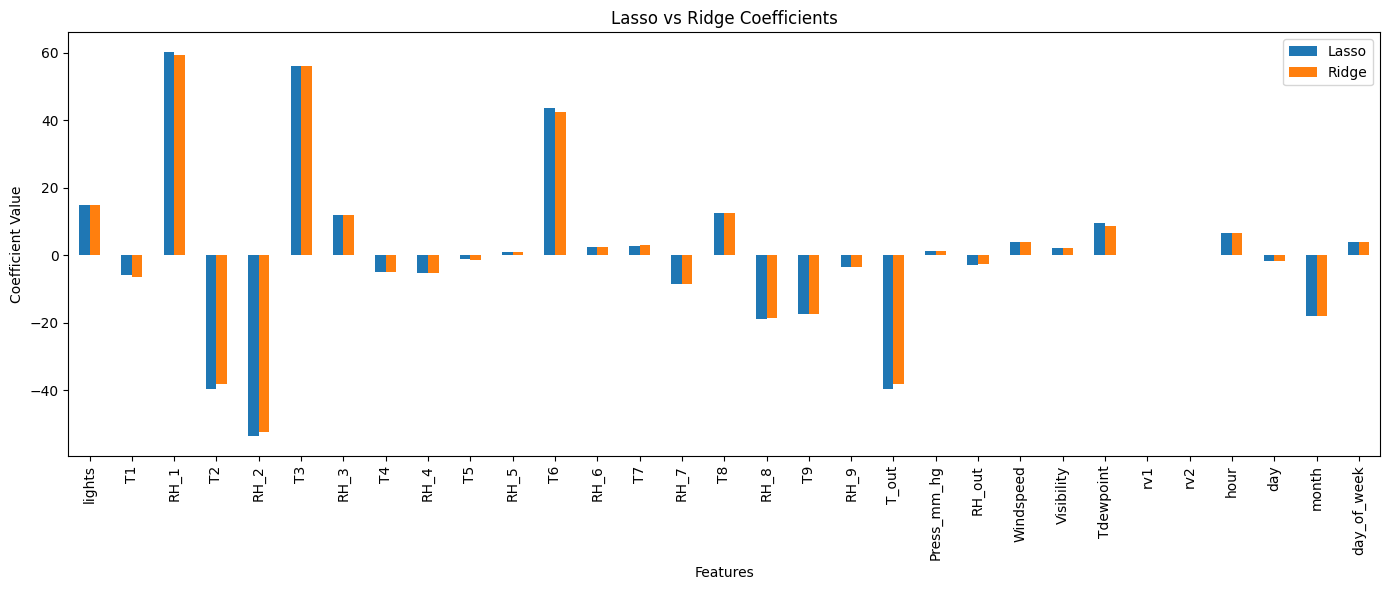

In [92]:
# Prepare coefficients for plotting

coefficient_plot = coefficient_comparison.set_index("Feature")

coefficient_plot.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Lasso vs Ridge Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()

### Model Comparison Interpretation

Linear Regression provides the baseline performance without regularization.

Lasso Regression applies L1 regularization and may remove less important features by assigning their coefficients a value of zero.

Ridge Regression applies L2 regularization and reduces the magnitude of coefficients while generally retaining all features.

The test-set MAE, MSE, RMSE, and R² values are used to compare the predictive performance of the three models.

The experimental results are used to determine how regularization affects prediction performance for this dataset.

## Task 8: Visualization

The performance of the Linear Regression, Lasso Regression, and Ridge Regression models is visualized using different plots.

The following visualizations are performed:

1. Actual vs Predicted values for Lasso Regression.
2. Actual vs Predicted values for Ridge Regression.
3. Comparison of Lasso and Ridge coefficients.
4. Cross-validation performance against different alpha values.
5. Comparison of MAE, RMSE, and R² for all three models.

These visualizations help understand model prediction performance, the effect of regularization, and the differences between Lasso and Ridge Regression.

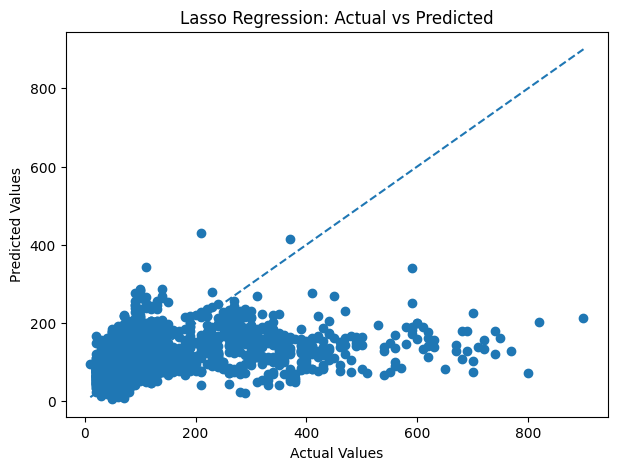

In [93]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_lasso)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Lasso Regression: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

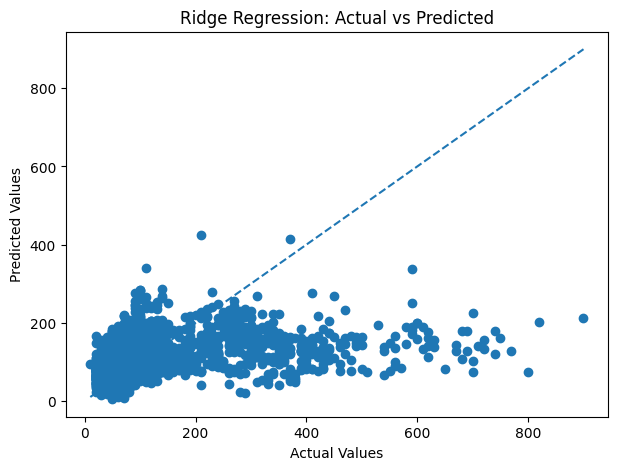

In [94]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_ridge)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Ridge Regression: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

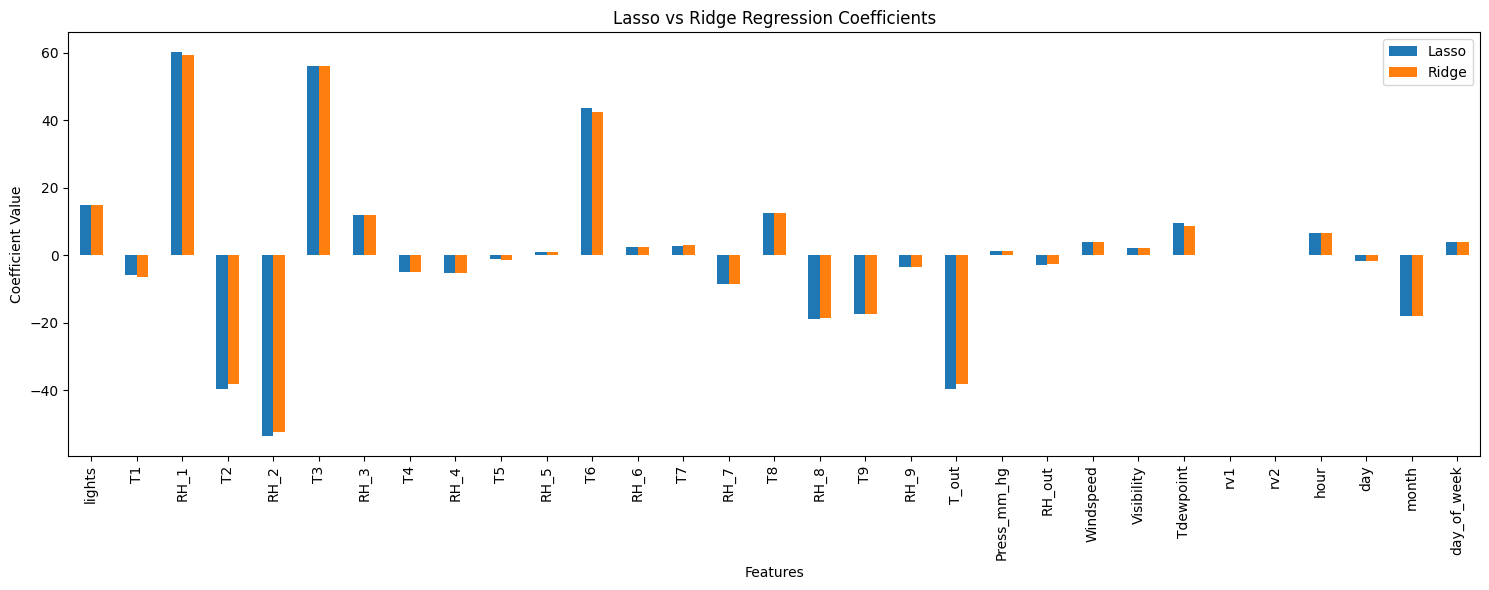

In [95]:
coefficient_plot = coefficient_comparison.set_index("Feature")

coefficient_plot.plot(
    kind="bar",
    figsize=(15, 6)
)

plt.title("Lasso vs Ridge Regression Coefficients")
plt.xlabel("Features")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [97]:
# Get Lasso GridSearchCV results
lasso_cv_results = pd.DataFrame(lasso_grid.cv_results_)

# Convert negative MSE into positive MSE
lasso_cv_results["CV_MSE"] = -lasso_cv_results["mean_test_score"]

# Display the results
lasso_cv_results[["param_alpha", "CV_MSE"]]

,param_alpha,CV_MSE
0,0.001,8880.136359
1,0.010,8879.901851
2,0.100,8883.129634
3,1.000,9049.976018
4,10.000,10055.497344
5,100.000,10638.684044


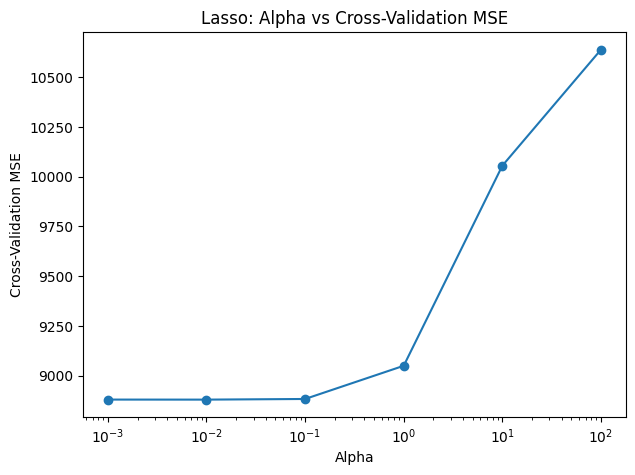

In [98]:
plt.figure(figsize=(7, 5))

plt.plot(
    lasso_cv_results["param_alpha"],
    lasso_cv_results["CV_MSE"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Cross-Validation MSE")
plt.title("Lasso: Alpha vs Cross-Validation MSE")

plt.show()

In [100]:
# Get Ridge GridSearchCV results
ridge_cv_results = pd.DataFrame(ridge_grid.cv_results_)

# Convert negative MSE into positive MSE
ridge_cv_results["CV_MSE"] = -ridge_cv_results["mean_test_score"]

# Display alpha and CV MSE
ridge_cv_results[["param_alpha", "CV_MSE"]]

,param_alpha,CV_MSE
0,0.001,8880.161597
1,0.010,8880.160826
2,0.100,8880.153192
3,1.000,8880.084260
4,10.000,8879.974298
5,100.000,8896.245676


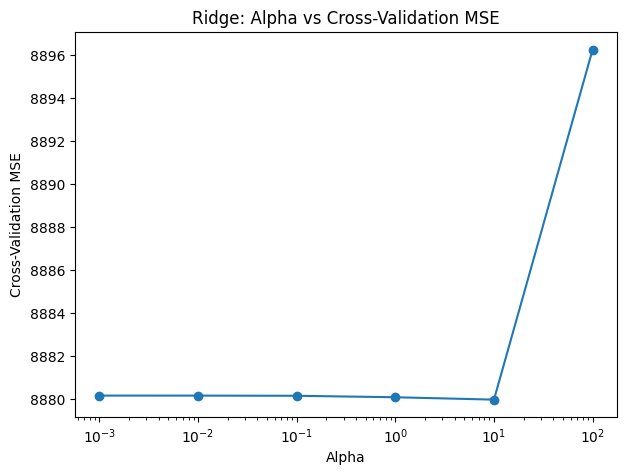

In [101]:
plt.figure(figsize=(7, 5))

plt.plot(
    ridge_cv_results["param_alpha"],
    ridge_cv_results["CV_MSE"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Alpha")
plt.ylabel("Cross-Validation MSE")
plt.title("Ridge: Alpha vs Cross-Validation MSE")

plt.show()

## Task 9: Interpretation

The results obtained from Linear Regression, Lasso Regression, and Ridge Regression are interpreted based on their test-set performance and coefficient values.

The following points are analyzed:

1. Effect of alpha on model performance.
2. Effect of regularization on model coefficients.
3. Importance of feature scaling.
4. Difference between Lasso and Ridge Regression.
5. Suitability of the models based on experimental results.

In [103]:
print("Linear Regression")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R2  :", r2_linear)

print("\nLasso Regression")
print("Best Alpha:", lasso_grid.best_params_["alpha"])
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE:", rmse_lasso)
print("R2  :", r2_lasso)

print("\nRidge Regression")
print("Best Alpha:", ridge_grid.best_params_["alpha"])
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE:", rmse_ridge)
print("R2  :", r2_ridge)

Linear Regression
MAE : 52.56973424453629
MSE : 8303.5409291266
RMSE: 91.1237670924913
R2  : 0.1702343017489495

Lasso Regression
Best Alpha: 0.01
MAE : 52.5499760679578
MSE : 8302.659885687803
RMSE: 91.11893264128922
R2  : 0.17032234366148102

Ridge Regression
Best Alpha: 10
MAE : 52.53727937919085
MSE : 8301.771993684817
RMSE: 91.11406035121482
R2  : 0.17041106994513722


In [104]:
coefficient_comparison

,Feature,Lasso,Ridge
0,lights,1.476248e+01,14.804751
1,T1,-5.740600e+00,-6.544712
2,RH_1,6.033466e+01,59.350943
3,T2,-3.969219e+01,-38.042712
4,RH_2,-5.369551e+01,-52.307417
5,T3,5.609855e+01,55.971928
6,RH_3,1.185519e+01,11.877023
7,T4,-4.889647e+00,-5.079416
8,RH_4,-5.115981e+00,-5.381429
9,T5,-1.210451e+00,-1.392027


### Interpretation of Results

#### 1. Effect of Alpha

Alpha controls the strength of regularization.

When alpha is small, the model applies less regularization and behaves more similarly to ordinary Linear Regression.

When alpha increases, stronger regularization is applied and the model coefficients are reduced.

GridSearchCV was used to select the alpha value that produced the lowest cross-validation MSE.

Therefore, the selected alpha is based on experimental cross-validation performance rather than choosing an alpha manually.

#### 2. Effect of Regularization on Coefficients

Regularization reduces the magnitude of model coefficients.

Lasso Regression uses L1 regularization and can reduce some coefficients exactly to zero. Therefore, Lasso can also perform feature selection.

Ridge Regression uses L2 regularization. It reduces the magnitude of coefficients but generally keeps all features in the model.

#### 3. Importance of Feature Scaling

Feature scaling is important because the dataset contains features with different numerical ranges.

StandardScaler was applied before training the models.

Scaling ensures that features with larger numerical values do not dominate the regularization penalty.

It is especially important for Lasso and Ridge because regularization directly affects the coefficient values.

#### 4. Lasso vs Ridge

Lasso is useful when some features may be unnecessary because it can reduce their coefficients to zero.

Ridge is useful when several features contribute to the prediction and their coefficients should be retained while being controlled.

The final suitability of Lasso or Ridge is determined by comparing their test-set MAE, MSE, RMSE, and R² values.

#### 5. Experimental Result

The Linear Regression, Lasso Regression, and Ridge Regression models were compared using the same test dataset.

Lower MAE, MSE, and RMSE indicate lower prediction error, while a higher R² indicates that the model explains more variation in energy consumption.

The model with the most suitable combination of these test metrics can be selected as the final model for this dataset.

## Task 10: Self-Learning

The objective of this self-learning activity is to understand how regularization can improve regression performance and reduce prediction error.

Different alpha values were tested using GridSearchCV with 5-fold cross-validation. The performance of Linear Regression, Lasso Regression, and Ridge Regression was then compared.

The main observations are:

- Regularization helps control large model coefficients.
- Lasso can perform feature selection by reducing some coefficients to zero.
- Ridge reduces coefficient magnitude while generally retaining all features.
- Feature scaling is important before applying Lasso and Ridge.
- GridSearchCV helps identify a suitable alpha value.
- Model performance should be evaluated using multiple metrics rather than relying on a single metric.
- For regression, reducing MAE, MSE, and RMSE and increasing R² are useful objectives.

The final model should be selected based on its performance on unseen test data and the requirements of the application.